<a href="https://colab.research.google.com/github/nishnarudkar/Interpretable-Machine-Learning-System-for-Parkinson-s-Disease-Detection-from-Speech-Biomarkers/blob/main/notebooks/Parkinsons_Detection_MLOPS_Project_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Parkinson's Dataset for Mlops Project/pd_speech_features.csv",header=1)

In [ ]:
df.head()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [ ]:
df.shape

(756, 755)

In [ ]:
df = df.drop("id", axis=1)

In [ ]:
df.shape

(756, 754)

In [ ]:
df["class"].value_counts()

,count
class,
1,564
0,192


In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(604, 753)
(152, 753)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=100)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

In [ ]:
X_train_selected.shape

(604, 100)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_selected, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf.predict(X_test_selected)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8223684210526315
              precision    recall  f1-score   support

           0       0.71      0.51      0.60        39
           1       0.85      0.93      0.89       113

    accuracy                           0.82       152
   macro avg       0.78      0.72      0.74       152
weighted avg       0.81      0.82      0.81       152



In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test_selected)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc)

ROC AUC: 0.9130928068981166


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=500)

lr.fit(X_train_selected, y_train)

y_pred_lr = lr.predict(X_test_selected)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8157894736842105
              precision    recall  f1-score   support

           0       0.69      0.51      0.59        39
           1       0.85      0.92      0.88       113

    accuracy                           0.82       152
   macro avg       0.77      0.72      0.73       152
weighted avg       0.81      0.82      0.81       152



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_selected, y_train)

y_pred_rf = rf.predict(X_test_selected)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8223684210526315
              precision    recall  f1-score   support

           0       0.71      0.51      0.60        39
           1       0.85      0.93      0.89       113

    accuracy                           0.82       152
   macro avg       0.78      0.72      0.74       152
weighted avg       0.81      0.82      0.81       152



In [ ]:
from sklearn.svm import SVC

svm = SVC(probability=True)

svm.fit(X_train_selected, y_train)

y_pred_svm = svm.predict(X_test_selected)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8157894736842105
              precision    recall  f1-score   support

           0       0.72      0.46      0.56        39
           1       0.83      0.94      0.88       113

    accuracy                           0.82       152
   macro avg       0.78      0.70      0.72       152
weighted avg       0.81      0.82      0.80       152



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train_selected, y_train)

y_pred_gb = gb.predict(X_test_selected)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8355263157894737
              precision    recall  f1-score   support

           0       0.77      0.51      0.62        39
           1       0.85      0.95      0.90       113

    accuracy                           0.84       152
   macro avg       0.81      0.73      0.76       152
weighted avg       0.83      0.84      0.82       152



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_selected, y_train)

y_pred_knn = knn.predict(X_test_selected)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8618421052631579
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        39
           1       0.88      0.94      0.91       113

    accuracy                           0.86       152
   macro avg       0.83      0.79      0.81       152
weighted avg       0.86      0.86      0.86       152



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_selected, y_train)

y_pred_dt = dt.predict(X_test_selected)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8223684210526315
              precision    recall  f1-score   support

           0       0.68      0.59      0.63        39
           1       0.86      0.90      0.88       113

    accuracy                           0.82       152
   macro avg       0.77      0.75      0.76       152
weighted avg       0.82      0.82      0.82       152



In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train_selected, y_train)

y_pred_xgb = xgb.predict(X_test_selected)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8947368421052632
              precision    recall  f1-score   support

           0       0.90      0.67      0.76        39
           1       0.89      0.97      0.93       113

    accuracy                           0.89       152
   macro avg       0.90      0.82      0.85       152
weighted avg       0.89      0.89      0.89       152



In [ ]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm,
    "Gradient Boosting": gb,
    "KNN": knn,
    "Decision Tree": dt,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    print(name, ":", acc)

Logistic Regression : 0.8157894736842105
Random Forest : 0.8223684210526315
SVM : 0.8157894736842105
Gradient Boosting : 0.8355263157894737
KNN : 0.8618421052631579
Decision Tree : 0.8223684210526315
XGBoost : 0.8947368421052632


In [ ]:
import pandas as pd

results = {
"Model": [
"Logistic Regression",
"Random Forest",
"SVM",
"Gradient Boosting",
"KNN",
"Decision Tree",
"XGBoost"
],

"Accuracy":[
0.8158,
0.8224,
0.8158,
0.8355,
0.8618,
0.8224,
0.8947
]
}

df_results = pd.DataFrame(results)

df_results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
6,XGBoost,0.8947
4,KNN,0.8618
3,Gradient Boosting,0.8355
1,Random Forest,0.8224
5,Decision Tree,0.8224
2,SVM,0.8158
0,Logistic Regression,0.8158


In [ ]:
selected_indices = selector.get_support(indices=True)

selected_features = X.columns[selected_indices]

print(selected_features)

Index(['DFA', 'numPulses', 'numPeriodsPulses', 'f1', 'VFER_mean',
       'VFER_entropy', 'mean_MFCC_2nd_coef', 'std_4th_delta', 'std_6th_delta',
       'std_7th_delta', 'std_8th_delta', 'std_9th_delta', 'std_10th_delta',
       'std_11th_delta', 'std_12th_delta', 'std_delta_delta_log_energy',
       'std_4th_delta_delta', 'std_6th_delta_delta', 'std_7th_delta_delta',
       'std_8th_delta_delta', 'std_9th_delta_delta', 'std_10th_delta_delta',
       'std_11th_delta_delta', 'std_12th_delta_delta',
       'app_entropy_shannon_1_coef', 'app_entropy_shannon_2_coef',
       'app_entropy_shannon_3_coef', 'app_entropy_shannon_4_coef',
       'app_entropy_shannon_5_coef', 'app_entropy_shannon_6_coef',
       'app_entropy_shannon_7_coef', 'app_entropy_shannon_8_coef',
       'app_entropy_shannon_9_coef', 'app_entropy_shannon_10_coef',
       'app_det_TKEO_mean_5_coef', 'app_det_TKEO_mean_6_coef',
       'app_det_TKEO_mean_7_coef', 'app_det_TKEO_mean_8_coef',
       'app_det_TKEO_mean_9_coef', '

In [ ]:
import pandas as pd

importance = xgb.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
72,tqwt_TKEO_std_dec_12,0.047150
54,tqwt_entropy_shannon_dec_13,0.040600
65,tqwt_entropy_log_dec_13,0.038005
15,std_delta_delta_log_energy,0.035007
36,app_det_TKEO_mean_7_coef,0.033906
68,tqwt_entropy_log_dec_16,0.032264
28,app_entropy_shannon_5_coef,0.031743
95,tqwt_maxValue_dec_13,0.028863
9,std_7th_delta,0.023590
76,tqwt_stdValue_dec_8,0.022349


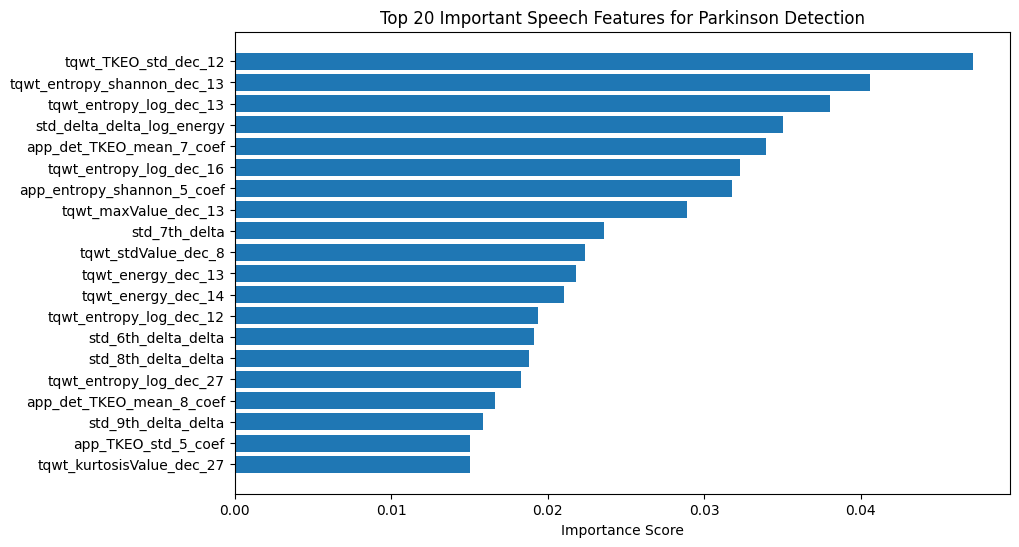

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Speech Features for Parkinson Detection")

plt.xlabel("Importance Score")

plt.show()

In [ ]:
importance = xgb.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    xgb,
    X_train_selected,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10)
)

In [ ]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

In [ ]:
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()

Dataset shape: (756, 754)

Class Distribution:
class
1    564
0    192
Name: count, dtype: int64

After SMOTE:
class
1    451
0    451
Name: count, dtype: int64

LogisticRegression
Accuracy: 0.8223684210526315
Precision: 0.8909090909090909
Recall: 0.8672566371681416
F1: 0.8789237668161435

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.69      0.67        39
           1       0.89      0.87      0.88       113

    accuracy                           0.82       152
   macro avg       0.77      0.78      0.77       152
weighted avg       0.83      0.82      0.82       152


RandomForest
Accuracy: 0.8552631578947368
Precision: 0.9026548672566371
Recall: 0.9026548672566371
F1: 0.9026548672566371

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        39
           1       0.90      0.90      0.90       113

    accuracy                           0.86     

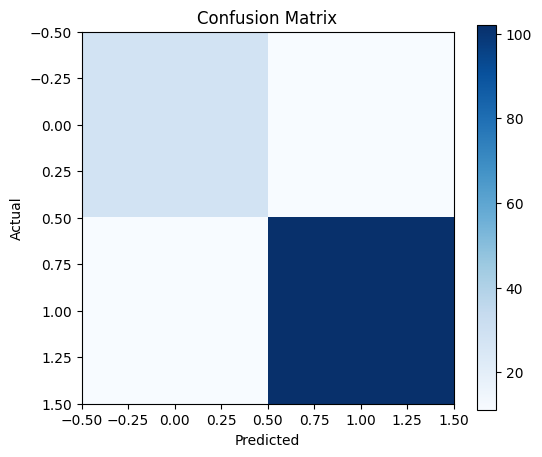


ROC AUC: 0.9208078057635579


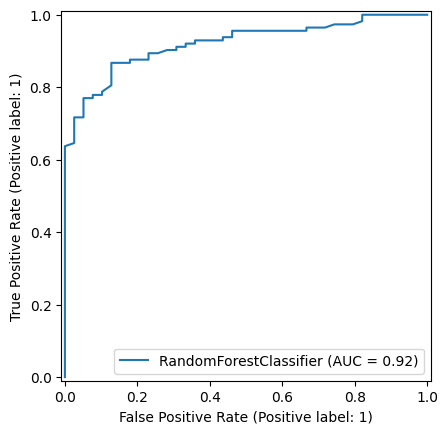

NameError: name 'feature_importance' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib
import os


# ----------------------------------
# Load Dataset
# ----------------------------------

df = df.drop("id", axis=1)

X = df.drop("class", axis=1)
y = df["class"]

print("Dataset shape:", df.shape)
print("\nClass Distribution:")
print(y.value_counts())


# ----------------------------------
# Train Test Split
# ----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ----------------------------------
# Handle Class Imbalance
# ----------------------------------

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train).value_counts())


# ----------------------------------
# Feature Selection
# ----------------------------------

selector = SelectKBest(score_func=f_classif, k=100)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]


# ----------------------------------
# Feature Scaling
# ----------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ----------------------------------
# Define Models
# ----------------------------------

models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss",
        random_state=42
    )
}


# ----------------------------------
# Train Models
# ----------------------------------

results = {}

best_model = None
best_acc = 0


for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results[name] = acc

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, pred))

    if acc > best_acc:
        best_acc = acc
        best_model = model


# ----------------------------------
# Model Comparison
# ----------------------------------

print("\nModel Accuracy Comparison:")
for k, v in results.items():
    print(k, ":", v)


# ----------------------------------
# Confusion Matrix
# ----------------------------------

best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


# ----------------------------------
# ROC Curve
# ----------------------------------

if hasattr(best_model, "predict_proba"):

    y_prob = best_model.predict_proba(X_test)[:,1]

    roc = roc_auc_score(y_test, y_prob)

    print("\nROC AUC:", roc)

    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.show()


# ----------------------------------
# SHAP Feature Importance
# ----------------------------------

if isinstance(best_model, XGBClassifier):

    explainer = shap.TreeExplainer(best_model)

    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values, X_test)


# ----------------------------------
# Extract Top Biomarkers
# ----------------------------------

if isinstance(best_model, XGBClassifier):

    importance = best_model.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": selected_features,
        "Importance": importance
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nTop 10 Speech Biomarkers:")
    print(feature_importance.head(10))


# ----------------------------------
# Plot Top Biomarkers
# ----------------------------------

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Speech Biomarkers for Parkinson Detection")

plt.xlabel("Importance Score")

plt.show()


# ----------------------------------
# Learning Curve (Bias Variance)
# ----------------------------------

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()

plt.title("Bias-Variance Learning Curve")

plt.show()


# ----------------------------------
# Save Best Model
# ----------------------------------

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/model.pkl")
joblib.dump(selector, "models/selector.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("\nBest Model Saved")
print("Best Accuracy:", best_acc)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn & Imblearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Load Data (Fixed missing '=' signs)
# Replace path with your actual Colab Drive path
df = pd.read_csv("/content/drive/MyDrive/Parkinson's Dataset for Mlops Project/pd_speech_features.csv", header=1)

# Drop 'id' column as it has no predictive value
df = df.drop("id", axis=1)

# Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

# 2. Train-Test Split (Stratified to maintain 75/25 ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Scaling
# Fit on training data ONLY, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Handle Imbalance with SMOTE
# CRITICAL: Apply SMOTE ONLY to the training data to prevent data leakage into the test set.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training class distribution:\n{y_train.value_counts()}")
print(f"Resampled training class distribution:\n{y_train_resampled.value_counts()}")

# 5. Non-Linear Feature Selection
# Using a Random Forest to select features instead of f_classif to capture complex, non-linear relationships.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SelectFromModel(rf_selector, max_features=100) # Keep top 100 features

X_train_selected = selector.fit_transform(X_train_resampled, y_train_resampled)
X_test_selected = selector.transform(X_test_scaled)

# Get the names of the selected features for later use
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]

# 6. Model Training & Evaluation Setup
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
}

results = []

# Loop through models, fit, and evaluate
for name, model in models.items():
    # Fit on the SMOTE-resampled, feature-selected data
    model.fit(X_train_selected, y_train_resampled)

    # Predict on the unseen test data
    y_pred = model.predict(X_test_selected)

    # Get probabilities for ROC AUC (KNN and SVC need probability=True, handled above)
    y_prob = model.predict_proba(X_test_selected)[:, 1]

    # Calculate robust metrics
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "ROC AUC": roc_auc,
        "Macro F1": macro_f1
    })

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))

# Display overall results sorted by ROC AUC
df_results = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
print("\nModel Comparison Table:")
print(df_results)

# 7. Cross-Validation and Hyperparameter Tuning (Example on XGBoost)
print("\n--- Tuning Top Model (XGBoost) with GridSearchCV ---")
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

# Use StratifiedKFold to ensure folds maintain the class balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    scoring='roc_auc', # Optimize for ability to distinguish classes
    cv=cv,
    n_jobs=-1 # Use all processors
)

grid_search.fit(X_train_selected, y_train_resampled)

print(f"Best XGBoost Parameters: {grid_search.best_params_}")
best_xgb = grid_search.best_estimator_

# Final Evaluation of the tuned model
y_pred_best = best_xgb.predict(X_test_selected)
print("\nBest XGBoost Classification Report:")
print(classification_report(y_test, y_pred_best))

Original training class distribution:
class
1    451
0    153
Name: count, dtype: int64
Resampled training class distribution:
class
1    451
0    451
Name: count, dtype: int64

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.64      0.74      0.69        39
           1       0.91      0.86      0.88       113

    accuracy                           0.83       152
   macro avg       0.78      0.80      0.79       152
weighted avg       0.84      0.83      0.83       152


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        39
           1       0.90      0.89      0.90       113

    accuracy                           0.85       152
   macro avg       0.80      0.81      0.80       152
weighted avg       0.85      0.85      0.85       152


--- SVM ---
              precision    recall  f1-score   support

           0       0.67      0.74      0.71      

Dataset Shape: (756, 754)

Class Distribution:
 class
1    564
0    192
Name: count, dtype: int64

After SMOTE:
 class
1    451
0    451
Name: count, dtype: int64

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.64      0.72      0.67        39
           1       0.90      0.86      0.88       113

    accuracy                           0.82       152
   macro avg       0.77      0.79      0.78       152
weighted avg       0.83      0.82      0.83       152


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.75      0.77      0.76        39
           1       0.92      0.91      0.92       113

    accuracy                           0.88       152
   macro avg       0.83      0.84      0.84       152
weighted avg       0.88      0.88      0.88       152


===== SVM =====
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        

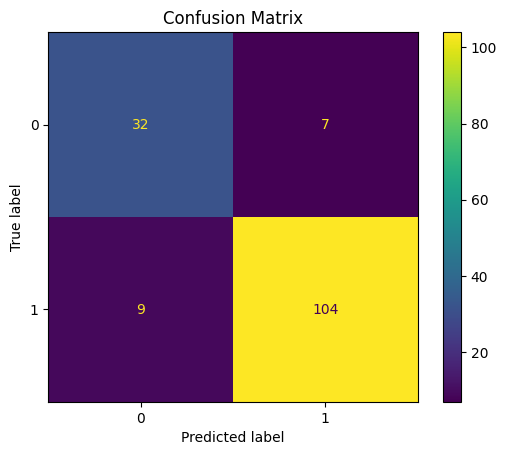

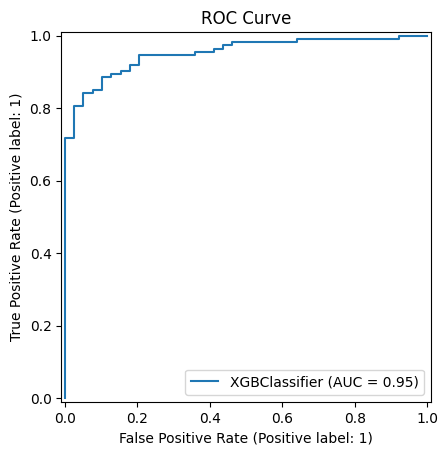


Top 10 Biomarkers:
                      Feature  Importance
58      tqwt_TKEO_mean_dec_12    0.147642
68       tqwt_TKEO_std_dec_13    0.098361
59      tqwt_TKEO_mean_dec_13    0.060553
49    tqwt_entropy_log_dec_16    0.030514
85       tqwt_minValue_dec_16    0.024126
12              std_6th_delta    0.023708
62      tqwt_TKEO_mean_dec_18    0.019888
10       std_delta_log_energy    0.019419
13              std_7th_delta    0.019403
94  tqwt_kurtosisValue_dec_17    0.015737


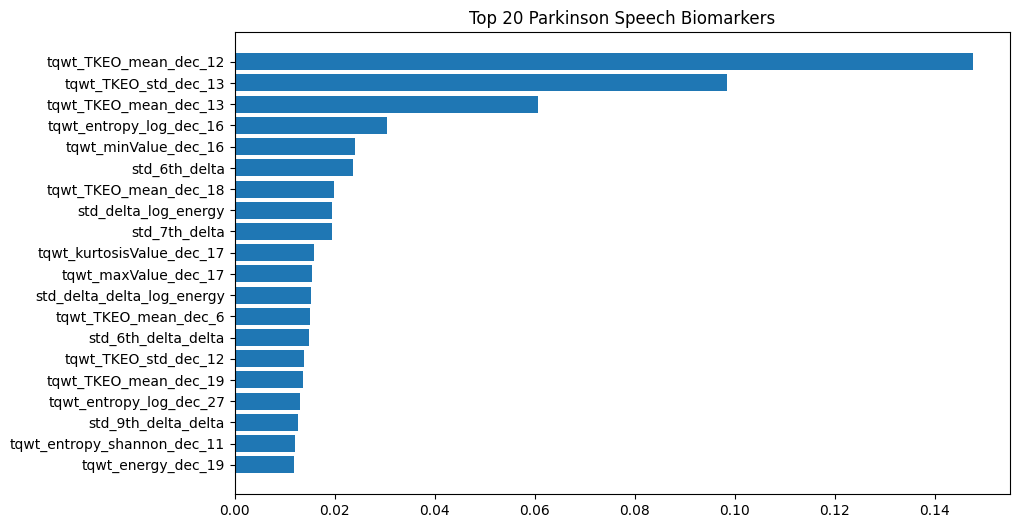


Generating SHAP explanations...


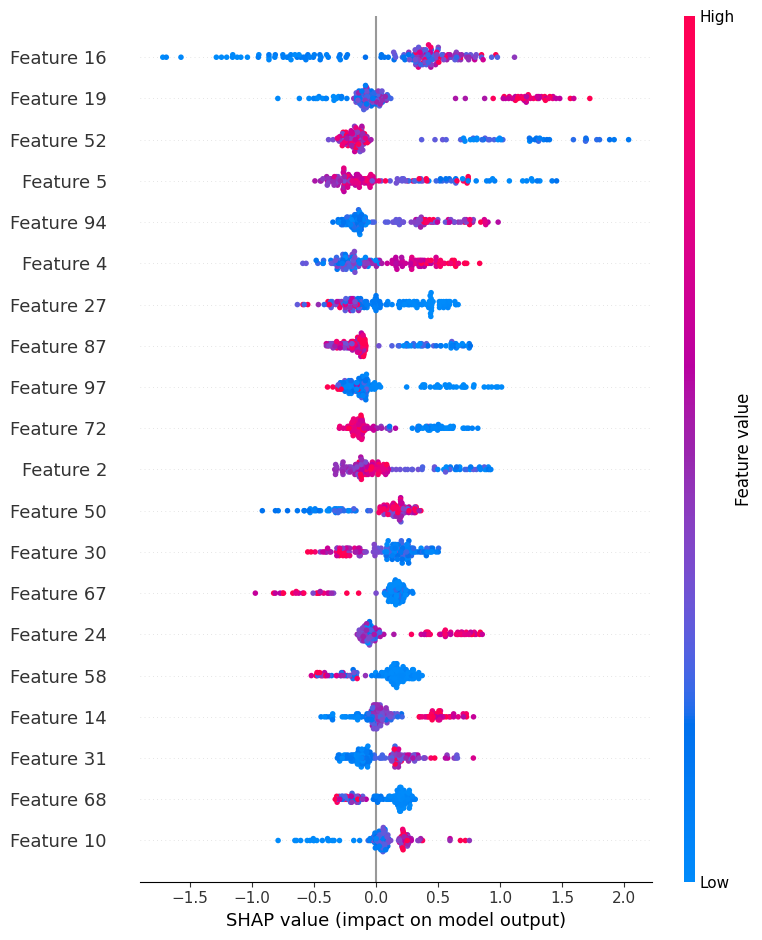

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expec

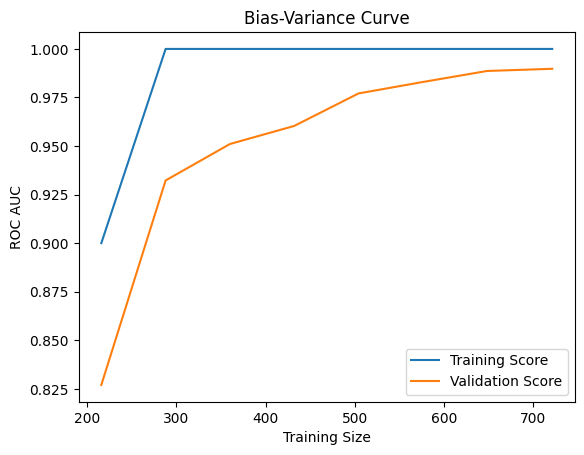


Model saved successfully!
Best ROC AUC: 0.9518947129566597


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# =========================================
# 1. LOAD DATA
# =========================================

df = df.drop("id", axis=1)

X = df.drop("class", axis=1)
y = df["class"]

print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", y.value_counts())


# =========================================
# 2. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================================
# 3. HANDLE IMBALANCE (SMOTE)
# =========================================
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:\n", pd.Series(y_train_resampled).value_counts())


# =========================================
# 4. FEATURE SELECTION (TREE BASED)
# =========================================
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)

selector = SelectFromModel(rf_selector, max_features=100)

X_train_selected = selector.fit_transform(X_train_resampled, y_train_resampled)
X_test_selected = selector.transform(X_test)

selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]


# =========================================
# 5. SCALING (ONLY FOR CERTAIN MODELS)
# =========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)


# =========================================
# 6. DEFINE MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss",
        random_state=42
    )
}


# =========================================
# 7. TRAIN + EVALUATE
# =========================================
results = []
best_model = None
best_score = 0
best_name = ""

for name, model in models.items():

    # Use scaled data only for certain models
    if name in ["Logistic Regression", "SVM", "KNN"]:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train_selected
        X_test_use = X_test_selected

    model.fit(X_train_use, y_train_resampled)

    y_pred = model.predict(X_test_use)
    y_prob = model.predict_proba(X_test_use)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "Model": name,
        "ROC AUC": roc_auc,
        "Macro F1": macro_f1
    })

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_name = name
        best_X_test = X_test_use
        best_X_train = X_train_use


# =========================================
# 8. RESULTS
# =========================================
df_results = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)

print("\nModel Comparison:\n", df_results)
print("\nBest Model:", best_name)


# =========================================
# 9. CONFUSION MATRIX
# =========================================
ConfusionMatrixDisplay.from_estimator(best_model, best_X_test, y_test)
plt.title("Confusion Matrix")
plt.show()


# =========================================
# 10. ROC CURVE
# =========================================
RocCurveDisplay.from_estimator(best_model, best_X_test, y_test)
plt.title("ROC Curve")
plt.show()


# =========================================
# 11. FEATURE IMPORTANCE (BIOMARKERS)
# =========================================
feature_importance = None

if hasattr(best_model, "feature_importances_"):

    importance = best_model.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": selected_features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

elif hasattr(best_model, "coef_"):

    importance = np.abs(best_model.coef_[0])

    feature_importance = pd.DataFrame({
        "Feature": selected_features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)


if feature_importance is not None:

    print("\nTop 10 Biomarkers:")
    print(feature_importance.head(10))

    top_features = feature_importance.head(20)

    plt.figure(figsize=(10,6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Top 20 Parkinson Speech Biomarkers")
    plt.show()


# =========================================
# 12. SHAP EXPLAINABILITY (FOR TREE MODELS)
# =========================================
if best_name in ["XGBoost", "Random Forest", "Gradient Boosting"]:

    print("\nGenerating SHAP explanations...")

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(best_X_test)

    shap.summary_plot(shap_values, best_X_test)


# =========================================
# 13. LEARNING CURVE (BIAS-VARIANCE)
# =========================================
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    best_X_train,
    y_train_resampled,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("ROC AUC")
plt.title("Bias-Variance Curve")
plt.legend()
plt.show()


# =========================================
# 14. SAVE MODEL FOR FASTAPI
# =========================================
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/model.pkl")
joblib.dump(selector, "models/selector.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("\nModel saved successfully!")
print("Best ROC AUC:", best_score)